# Atividade 1 - Processamento Digital de Imagens

In [220]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pathlib

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

BASE = pathlib.Path('listas/pdi_lista1/')

def carregar_imagens_gs():
    for file in BASE.iterdir():
        if file.is_file() and file.suffix in ['.jpg', '.png', '.jpeg']:
            yield file.name.split('.')[0], cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)

def exibir(img, titulo=''):
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

def mostrar_hist(img, titulo=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(titulo)
    axes[0].axis('off')

    hist, bins = np.histogram(img, bins=256, range=(0, 256))
    axes[1].bar(bins[:-1], hist, width=1)
    axes[1].set_title('Histograma - ' + titulo)
    axes[1].set_xlabel('Intensidade')
    axes[1].set_ylabel('N\u00ba de pixels')

    plt.tight_layout()
    plt.show()

def comparar_imgs(img1, img2, titulo1='', titulo2=''):
    """Exibe duas imagens lado a lado para comparação."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(titulo1)
    axes[0].axis('off')

    axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title(titulo2)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [221]:
imagens = { k: img for k, img in carregar_imagens_gs()}

for nome, img in imagens.items():
    print(f'{nome:20s} shape={img.shape} dtype={img.dtype}')

car                  shape=(394, 700) dtype=uint8
gato                 shape=(313, 500) dtype=uint8
saturn               shape=(309, 410) dtype=uint8
cc-w                 shape=(256, 256) dtype=uint8
Recife_antigo        shape=(853, 1280) dtype=uint8
img_1                shape=(500, 500) dtype=uint8
cc-c                 shape=(417, 626) dtype=uint8
img_2                shape=(277, 300) dtype=uint8
img_3                shape=(403, 360) dtype=uint8
upe                  shape=(703, 1280) dtype=uint8
toro                 shape=(960, 1280) dtype=uint8


## Questão 1 - Redimensionamento (500x500 -> 1280x720 | 300x277 -> 640x480 | 360x403 -> 640x480)

In [222]:

def resize(img, new_size):
    org_h , org_w = img.shape
    new_h, new_w = new_size
    resized_img = np.zeros((new_h, new_w), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):
            orig_x = round(i * org_h / new_h)
            orig_y = round(j * org_w / new_w)

            if orig_x >= org_h:
                orig_x = np.floor(i * org_h / new_h).astype(int)
            if orig_y >= org_w:
                orig_y = np.floor(j * org_w / new_w).astype(int)

            resized_img[i, j] = img[orig_x, orig_y]


    resized_img[i, j] = img[orig_x, orig_y]
    return resized_img

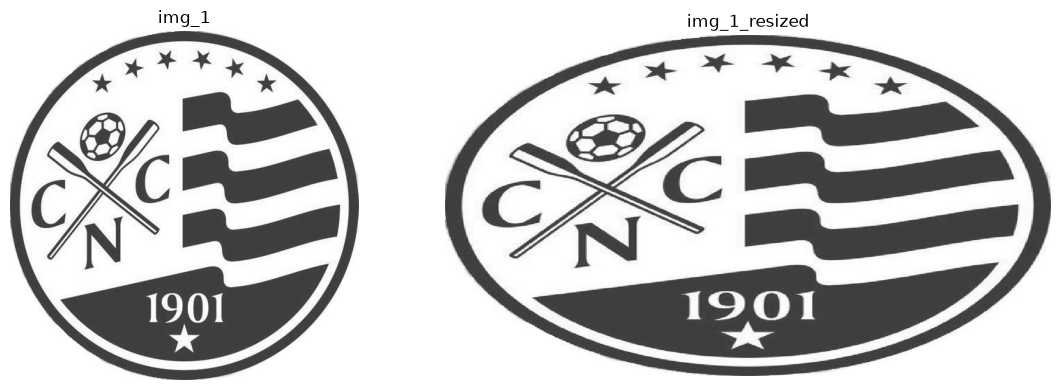

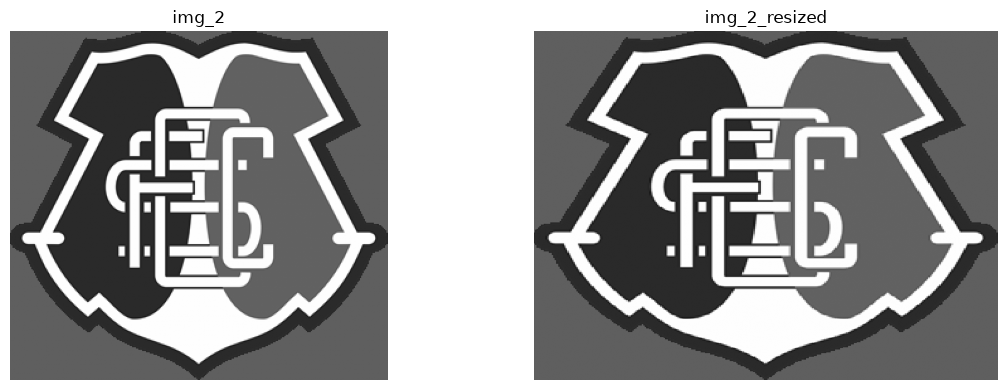

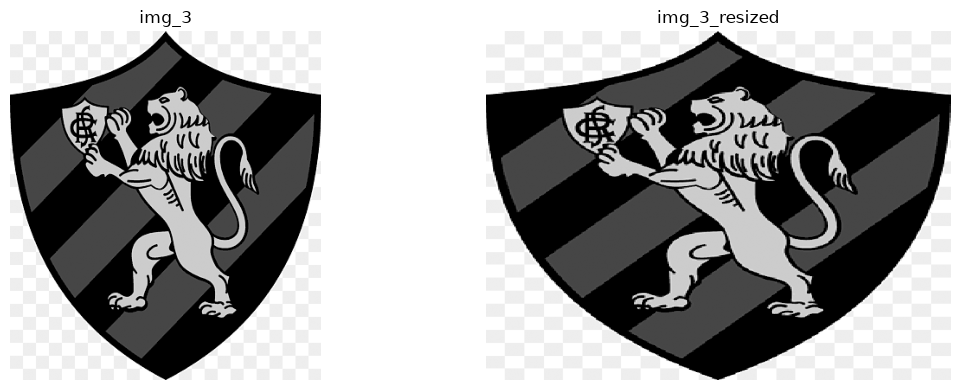

In [223]:
comparar_imgs(imagens['img_1'], resize(imagens['img_1'], (720, 1280)), 'img_1', 'img_1_resized')
comparar_imgs(imagens['img_2'], resize(imagens['img_2'], (480, 640)), 'img_2', 'img_2_resized')
comparar_imgs(imagens['img_3'], resize(imagens['img_3'], (480, 640)), 'img_3', 'img_3_resized')

## Questão 2 - Composição HD (img_1 + img_2 + img_3 lado a lado, final 1280x720)

In [224]:
def concaternar(imgs, new_size):
    target_h, target_w = new_size
    target_w = target_w // len(imgs)
    new_size = (target_h, target_w)
    resized_imgs = [resize(img, new_size) for img in imgs]
    return np.hstack(resized_imgs)

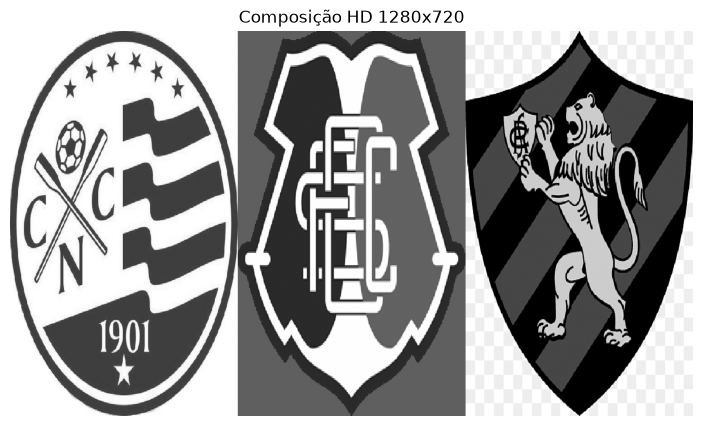

In [225]:
concatenada = concaternar([imagens['img_1'], imagens['img_2'], imagens['img_3']], (720, 1280))
exibir(concatenada, 'Composição HD 1280x720')

## Questão 3 - Contraste e brilho (gato.jpg, Recife_antigo.jpg, upe.jpg)

In [226]:
def contraste_brilho(img, contraste=1.0, brilho=0):
    img = img.astype(np.float64) 
    img = img * contraste + brilho
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

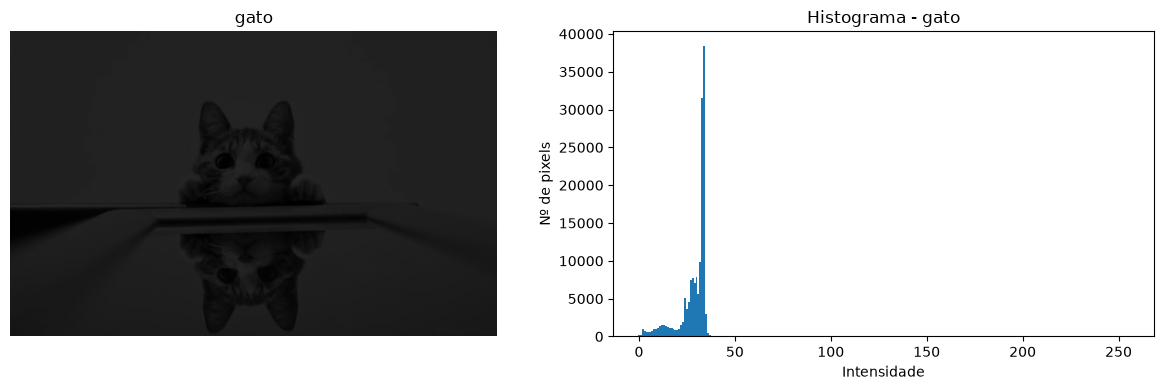

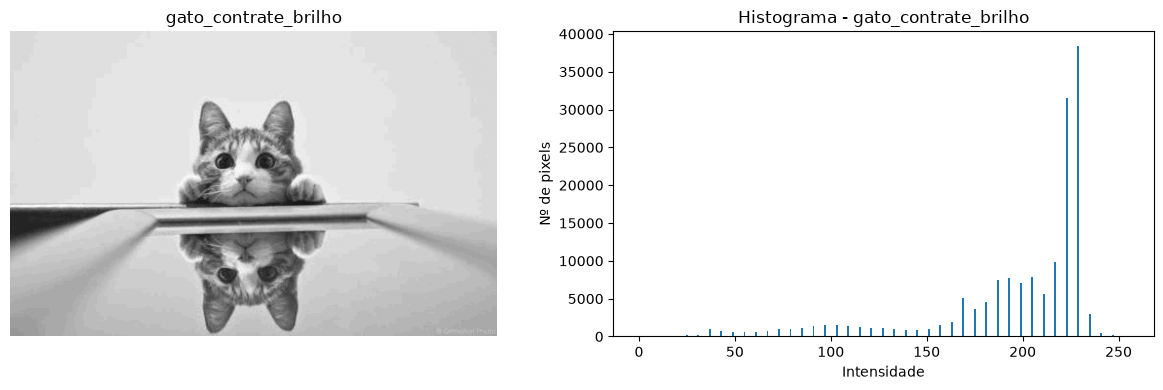

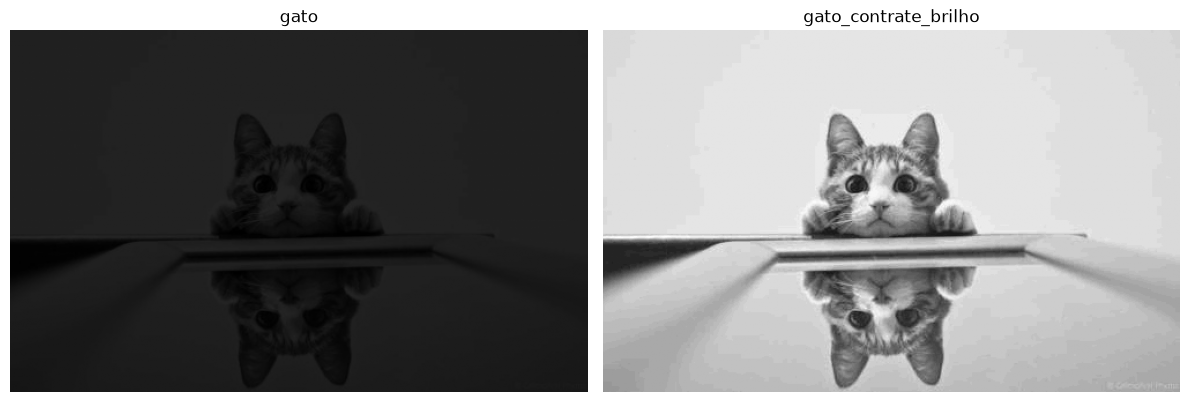

In [227]:
gato = contraste_brilho(imagens['gato'], contraste=6, brilho=25)
mostrar_hist(imagens['gato'], 'gato')
mostrar_hist(gato, 'gato_contrate_brilho')
comparar_imgs(imagens['gato'], gato, 'gato', 'gato_contrate_brilho')

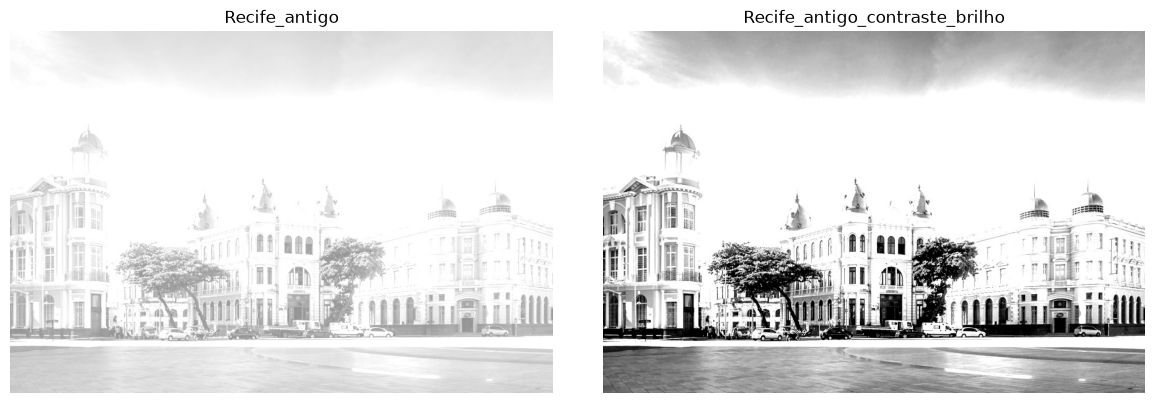

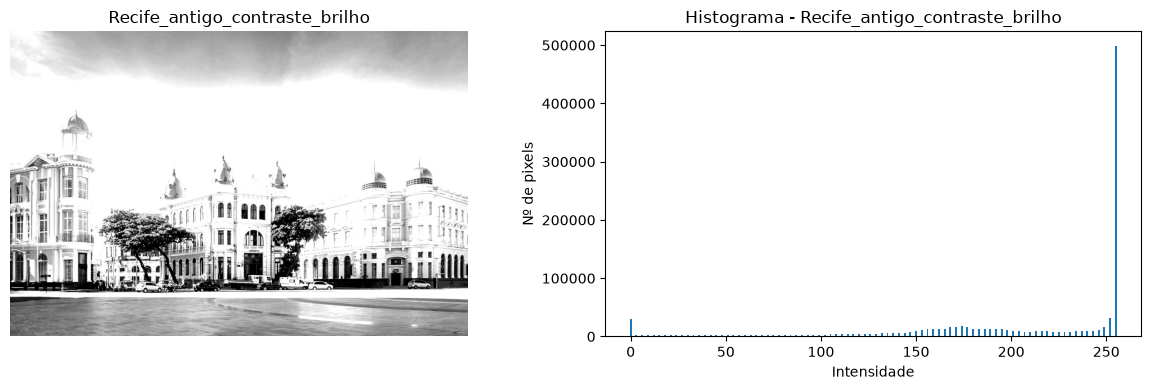

In [228]:
recife_antigo_contraste_brilho = contraste_brilho(imagens['Recife_antigo'], contraste=3, brilho=-510)
comparar_imgs(imagens['Recife_antigo'], recife_antigo_contraste_brilho, 'Recife_antigo', 'Recife_antigo_contraste_brilho')
mostrar_hist(recife_antigo_contraste_brilho, 'Recife_antigo_contraste_brilho')

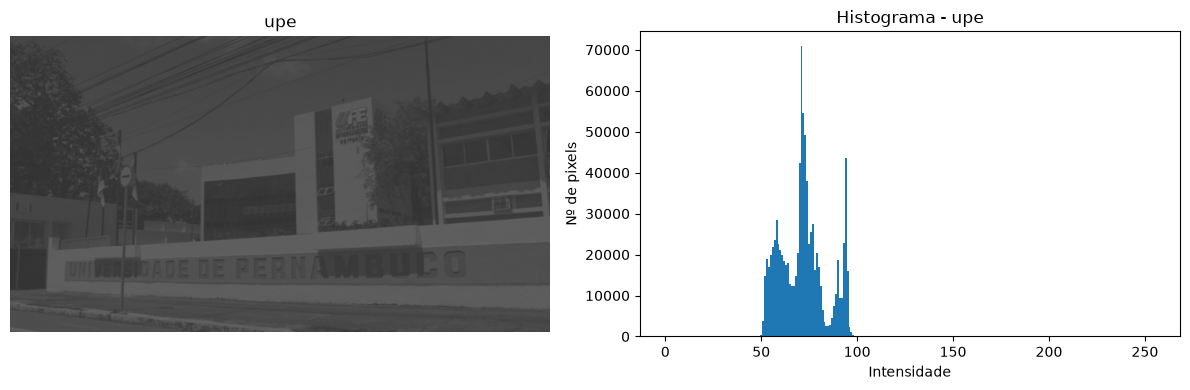

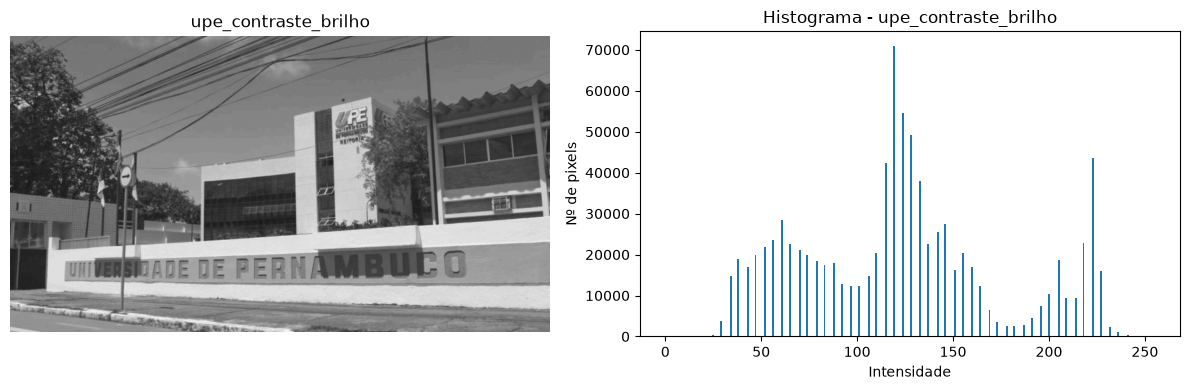

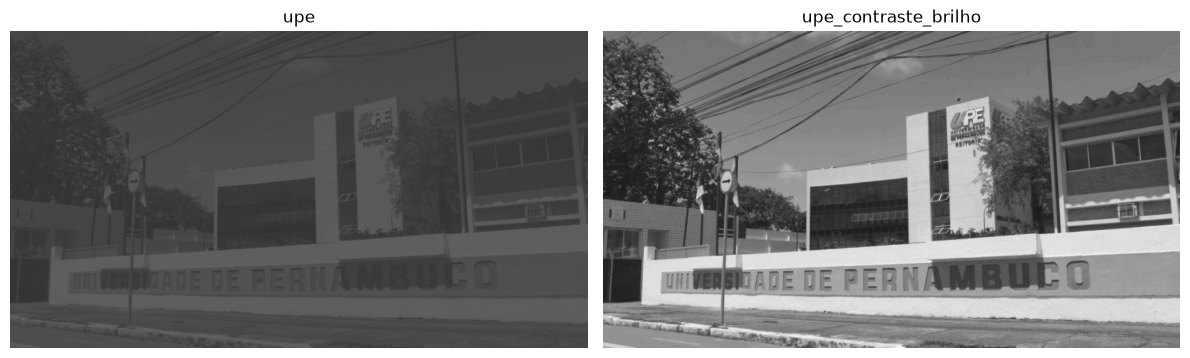

In [229]:
upe_contraste_brilho = contraste_brilho(imagens['upe'], contraste=4.5, brilho=-200)
mostrar_hist(imagens['upe'], 'upe')
mostrar_hist(upe_contraste_brilho, 'upe_contraste_brilho')
comparar_imgs(imagens['upe'], upe_contraste_brilho, 'upe', 'upe_contraste_brilho')

## Questão 4 - Remoção de ruído (cc-w.jpg, saturn.png, toro.jpg)

In [247]:
def apply_filter(img, kernel):
      kernel = kernel.astype(np.float64)
      pad = kernel.shape[0] // 2
      padded = np.pad(img, pad, mode='edge').astype(np.float64)
      h, w = img.shape
      out = np.zeros((h, w), dtype=np.float64)
      for i in range(h):
          for j in range(w):
              window = padded[i:i+2*pad+1, j:j+2*pad+1]
              out[i, j] = np.sum(window * kernel)
      return np.clip(out, 0, 255).astype(np.uint8)

def filtro_salt_peper(img, kernel_size=3, threshold=0.05):
    new_img = np.zeros_like(img)
    shift = kernel_size // 2
    
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] <= (threshold * 255) or img[i, j] >= (255 - (threshold * 255)):
                new_img[i, j] = np.median(img[max(0, i-shift):min(img.shape[0], i+shift+1), max(0, j-shift):min(img.shape[1], j+shift+1)])
            else:
                new_img[i, j] = img[i, j]
    return new_img

In [231]:
def filtro_mediano(img, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size)) * np.median(img)
    return apply_filter(img, kernel)

def filtro_blur(img, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)
    return apply_filter(img, kernel)

def filtro_gaussiano(img, kernel_size=3, sigma=1.0):
    ax = np.linspace(-(kernel_size - 1) / 2., (kernel_size - 1) / 2., kernel_size)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sigma))
    kernel = np.outer(gauss, gauss)
    kernel /= np.sum(kernel)

    return apply_filter(img, kernel)

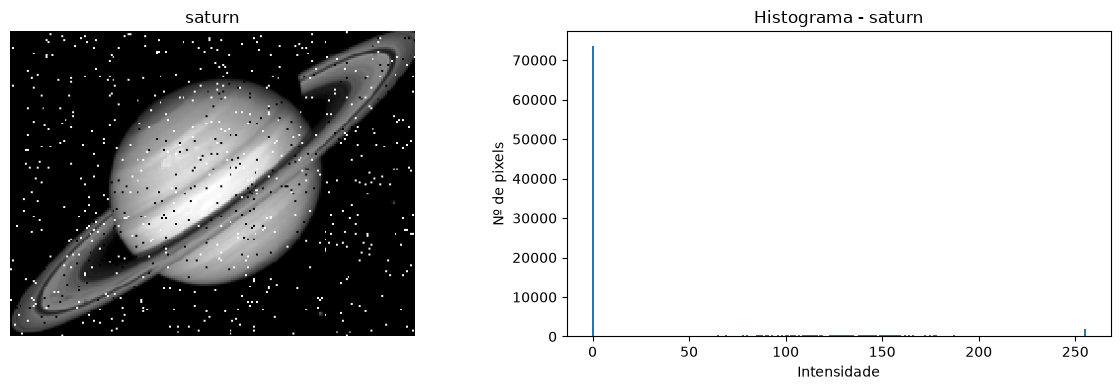

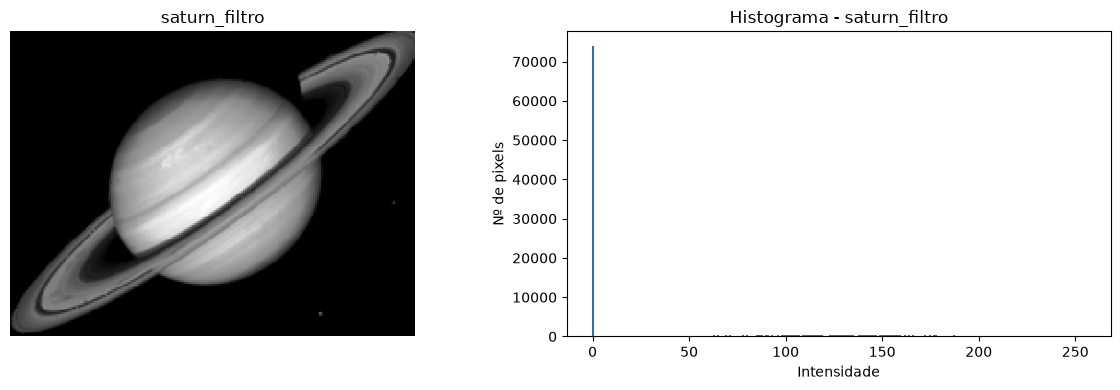

In [248]:
saturno_filtro = filtro_salt_peper(imagens['saturn'], kernel_size=5)
mostrar_hist(imagens['saturn'], 'saturn')
mostrar_hist(saturno_filtro, 'saturn_filtro')

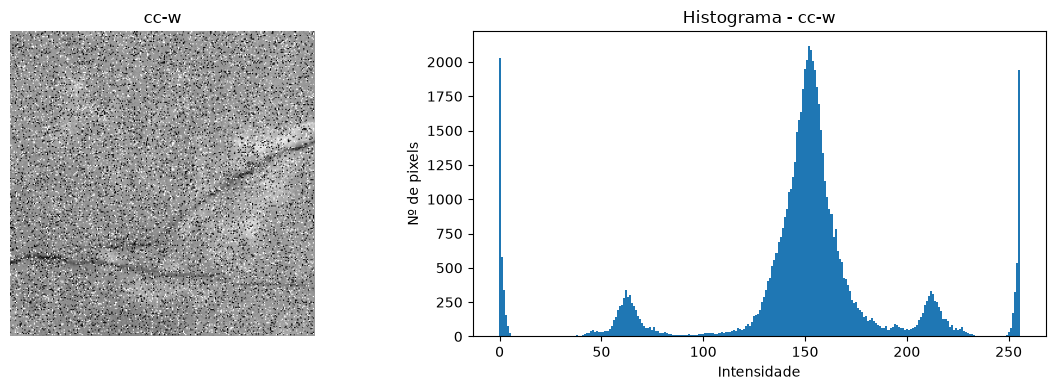

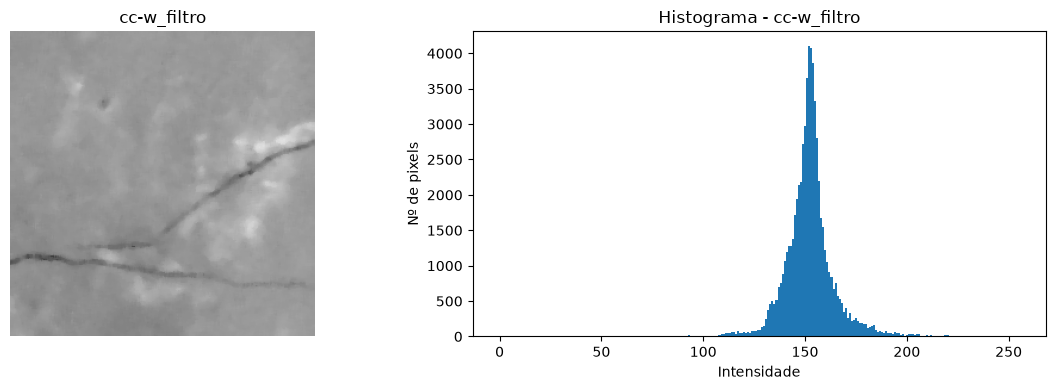

In [254]:
cc_w_filtro = filtro_salt_peper(imagens['cc-w'], kernel_size=5, threshold=1)
contraste_brilho(cc_w_filtro, contraste=2, brilho=0)
mostrar_hist(imagens['cc-w'], 'cc-w')
mostrar_hist(cc_w_filtro, 'cc-w_filtro')

## Questão 5 - Musgo tipo sal-e-pimenta (cc-c.jpg)

In [272]:
cc_c_filtro = filtro_salt_peper(imagens['cc-c'], kernel_size=5, threshold=1)


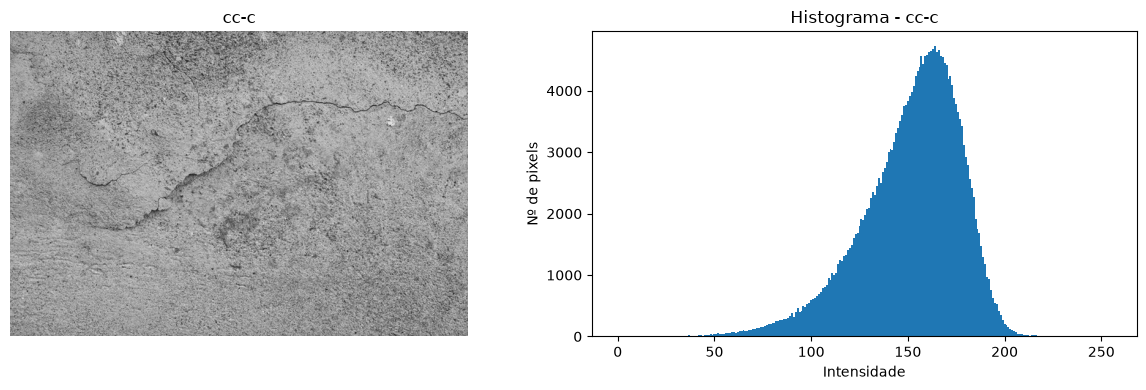

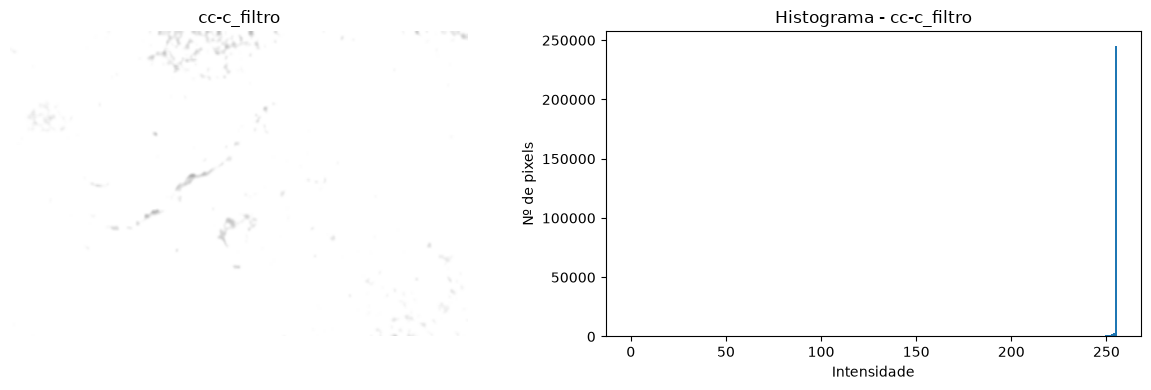

In [ ]:
kernel = np.array([
  [1, 1, 1],
  [0, 0, 0], 
  [1, 1, 1]
], dtype=np.float64)
kernel = kernel / np.sum(kernel)  # Normalize the kernel

cc_c_filtro = apply_filter(cc_c_filtro, kernel)
mostrar_hist(imagens['cc-c'], 'cc-c')
mostrar_hist(cc_c_filtro, 'cc-c_filtro')

## Questão 6 - Desafio: motion blur na placa (car.jpg)